# Module: Loading HACC stellar catalog

> Importing the stellar catalogs compiled from HACC. This module may be edited for a different file reader if necessary. 

## The entries in the current stellar catalog are: 

### *[fof_halo_tag, if_satellite, galaxy_tag, stellar_idx, metallicity, mass, age, x, y, z, vx, vy, vz]*

- galaxy_tag: Tags to galaxies given in the HACC datasets
- stellar idx: Unique ID for individual particles
- metallicity: Fraction of the metals in the stellar particles (Not rescaled by Zsun)
- mass: Mass of the stellar particle in Msun units
- age: Age of the stellar particles in 1/H0 units 
- x, y, z: Particle positions in Mpc/h units
- vx, vy, vz: Velocity of the particles

In [ ]:
#| default_exp load_sim_stellar_catalog

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export

import numpy as np
import os
import matplotlib.pylab as plt
import pkg_resources
import logging
import opencosmo as oc

/lcrc/project/cosmo_ai/nramachandra/Projects/tmp/ipykernel_1934691/1191991461.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
#| hide 

import seaborn as sns
import pandas as pd

In [ ]:
#| export

GALS_DIR = "data/test_hacc_stellar_catalog/"
GALS_FILE = pkg_resources.resource_stream("watercolor", GALS_DIR + "Gal_Z0.txt").name
# OPEN_COSMO_FILE = pkg_resources.resource_stream("watercolor", GALS_DIR + "haloparticles_2gpc.hdf5").name

In [ ]:
#| export

Z_SOLAR_HACC = 0.012899 # Solar metallicity value in HACC Hydro
Z_SOLAR_PADOVA = 0.019 # Solar metallicity value in Padova 
H0 = 71.0 # Hubble Constant in HACC Hydro

In [ ]:
#| export

def _convert_metallicity(hacc_metallicity:np.array=None, # Metallicity values from HACC  
                         Z_solar:np.float32=Z_SOLAR_PADOVA, # Z_solar value from Padova
                        )-> np.array: # Metallicity array in Z/Z_solar units
    return hacc_metallicity/Z_solar

def _convert_age(hacc_age:np.array=None, #Age in 1/H0 units 
                 H0:np.float32=H0, # LastJourney H0 value
                )-> np.array: #Age in Gyr 
    '''
    (hacc_age is in 1/H0 units)
    H0 = (71 km/s/Mpc) x (1 Mpc/3.08 x 1e19 km) = 2.37 x 1e−18 1/s
    '''
    # https://www.e-education.psu.edu/astro801/content/l10_p5.html
    
    H0_per_sec = H0*(1/(3.08*1e19)) #seconds
    one_over_H0 = 1/H0_per_sec/(3.1536*1e16)
    # age_hydro_gyr = hacc_age*one_over_H0     ### NOT SURE IF THE AGE is COSMIC (13.7 - age) or (age)

    age_hydro_gyr = one_over_H0 - hacc_age*one_over_H0  
    
    # print(age_hydro_gyr, one_over_H0)
    
    return age_hydro_gyr

In [ ]:
#| export

def load_hacc_galaxy_data(fileIn:str=GALS_FILE, # Input galaxy catalog file from HACC hydro sim
                              Z_solar:np.float32=Z_SOLAR_PADOVA, #Solar metallicity
                              H0:np.float32=H0, # Hubble constant
                              ) -> tuple: # galaxy_tag, stellar_indices, metallicity, mass, age, x, y, z
    
    fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = np.loadtxt(fileIn, 
                                                                 skiprows=1, 
                                                                 unpack=True)
    
    metal_z_solar = _convert_metallicity(metal, Z_solar)
    
    age_gyr = _convert_age(age, H0)
    
    return fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal_z_solar, mass, age_gyr, x, y, z, vx, vy, vz

In [ ]:
#| export

def load_opencosmo_collection(
    particle_file_path:str = None, # Path to the OpenCosmo particle file
    catalog_file_path:str = None, # Path to the OpenCosmo catalog file
    ) -> oc.StructureCollection: # OpenCosmo particle collection


    collection = oc.open(particle_file_path,catalog_file_path).with_units("physical")
    # data = oc.open(particle_file_path).with_units("physical")
    # print(data)
    return collection

In [ ]:
#| export

def read_particles_in_a_galaxy(
    particle_file_path: str = None, # Path to the HDF5 file containing  particle data
    catalog_file_path:str = None, # Path to the OpenCosmo catalog file
    unique_gal_tags:list = None # Unique identifier for the halo to filter particles
) -> oc.Dataset: # OpenCosmo dataset containing particles of a specific halo
    try:
        collection = load_opencosmo_collection(particle_file_path, catalog_file_path)
        # print(collection)
        
        selected_gal = collection.filter(oc.col('gal_tag').isin(unique_gal_tags))#.take(1,at='random')
        selected_star_particles = selected_gal["star_particles"]

        return selected_star_particles
    except Exception as e:
        logging.error("Failed to load halo catalog: %s", e)
        raise RuntimeError(f"Failed to load halo catalog: {e}")

In [ ]:
#|eval: false

particle_file_path = "/lcrc/project/cosmo_ai/nramachandra/Projects/Hydro_paint/Data/fromFE/haloparticles_2gpc.hdf5"
dirIn0 = "/lcrc/project/cosmo_ai/nramachandra/Projects/Hydro_paint/Data/fromSciDAC/128MPC_RUNS_HACC_5PARAM/reformat/"
dirIn1 = "KAPPA_2.127_EGW_0.479_SEED_7.143e5_VKIN_3794_EPS_9.752/output/"
dirIn2 = "step_624/"
dirIn3a = "galaxyparticles/"
dirIn3b = "galaxyproperties/"


particle_file_path = os.path.join(dirIn0, dirIn1, dirIn2, dirIn3a, "m000p-624.galaxyparticles.hdf5")
catalog_file_path = os.path.join(dirIn0, dirIn1, dirIn2, dirIn3b, "m000p-624.galaxyproperties.hdf5")


# ########################################################

# print(f"Particle file path: {particle_file_path}")
# print(f"Catalog file path: {catalog_file_path}")    

# collection = load_opencosmo_collection(particle_file_path, catalog_file_path)
# print(collection)
# gal_properties = collection["galaxy_properties"]
# star_particles = collection["star_particles"]

# print(star_particles.data.columns)
# print(gal_properties.data.columns)


# # ##########################

# halo_ids_select = [35324, 268404180]
# gal_tags_select = gal_properties.filter(oc.col('fof_halo_tag').isin(halo_ids_select)).data["gal_tag"].data


# ##########################

# # gal_tags_select = gal_properties.data["gal_tag"][30: 32]
# print('Selected galaxy tag: ', gal_tags_select)


# star_particles = read_particles_in_a_galaxy(
#     particle_file_path=particle_file_path,
#     catalog_file_path=catalog_file_path,
#     unique_gal_tags=gal_tags_select)

# print(star_particles.columns)

In [ ]:
#| export 

def load_hacc_galaxy_data_opencosmo(particle_file_path: str = None,  # Input galaxy catalog file from HACC hydro sim        
                             catalog_file_path:str = None,  # Path to the OpenCosmo catalog file                       
                             Z_solar: np.float32 = Z_SOLAR_PADOVA,  # Solar metallicity                               
                             H0: np.float32 = H0,  # Hubble constant                               
                             ) -> tuple:  # galaxy_tag, stellar_indices, metallicity, mass, age, x, y, z          
    
    # catalog = read_catalog(particle_file_path, catalog_file_path)

    collection = load_opencosmo_collection(particle_file_path, catalog_file_path)

    gal_properties = collection["galaxy_properties"]
    star_particles = collection["star_particles"]

    print('Number of available haloes in the catalog: ', np.unique(gal_properties.data["fof_halo_tag"]).size)

    ###################################
    ### below lines can be edited to keep all haloes or a random selection of haloes
    np.random.seed(42)  # For reproducibility
    num_random_halos = 200  # Number of random halos to select for testing
    selected_random_indices = np.random.randint(0, np.unique(gal_properties.data["fof_halo_tag"]).size, num_random_halos) # Randomly select 10 halos for testing
    unique_fof_halo_tags_list = np.unique(gal_properties.data["fof_halo_tag"])[selected_random_indices] # Limiting to random 10 haloes for testing
    ####################################


    print('Number of available haloes selected: ', unique_fof_halo_tags_list.size)


    # print(f" ==== Loaded catalog with {len(catalog.data)} rows and {len(catalog.data.columns)} columns. ====")
    
    # Initialize lists to collect data from all halos
    all_fof_halo_tags = []
    all_if_satellites = []
    all_gal_tags = []
    all_stellar_idx = []
    all_metals = []
    all_masses = []
    all_ages = []
    all_x = []
    all_y = []
    all_z = []
    all_vx = []
    all_vy = []
    all_vz = []
    
    for unique_fof_halo_tag in unique_fof_halo_tags_list:
        # print(f"Unique Halo Tag: {unique_fof_halo_tag}")

        selected_gal_tags = gal_properties.filter(oc.col('fof_halo_tag').isin(unique_fof_halo_tag)).data["gal_tag"].data
        # print("Selected Galaxy Tags:", selected_gal_tags)


        # Load particles for this galaxy
        star_particles = read_particles_in_a_galaxy(
            particle_file_path=particle_file_path,
            catalog_file_path=catalog_file_path,
            unique_gal_tags=selected_gal_tags)
        
        
        # Extract particle data for this halo
        x = star_particles.data['x']
        y = star_particles.data['y']
        z = star_particles.data['z']
        
        vx = star_particles.data['vx']
        vy = star_particles.data['vy']
        vz = star_particles.data['vz']
        
        fof_halo_tag = unique_fof_halo_tag*np.ones_like(x)
        mass = star_particles.data['mass']
        age = star_particles.data['age']
        metal = star_particles.data['zmet']
        stellar_idx = star_particles.data['id']
        
        if_satellite = np.ones_like(x)  # Assuming all particles are not satellites
        gal_tag = star_particles.data['gal_tag']  # Assuming no specific galaxy tag
        
        # Append data from this halo to the master arrays
        all_fof_halo_tags.append(fof_halo_tag)
        all_if_satellites.append(if_satellite)
        all_gal_tags.append(gal_tag)
        all_stellar_idx.append(stellar_idx)
        all_metals.append(metal)
        all_masses.append(mass)
        all_ages.append(age)
        all_x.append(x)
        all_y.append(y)
        all_z.append(z)
        all_vx.append(vx)
        all_vy.append(vy)
        all_vz.append(vz)
    
    # Concatenate all arrays
    fof_halo_tag = np.concatenate(all_fof_halo_tags)
    if_satellite = np.concatenate(all_if_satellites)
    gal_tag = np.concatenate(all_gal_tags)
    stellar_idx = np.concatenate(all_stellar_idx)
    metal = np.concatenate(all_metals)
    mass = np.concatenate(all_masses)
    age = np.concatenate(all_ages)
    x = np.concatenate(all_x)
    y = np.concatenate(all_y)
    z = np.concatenate(all_z)
    vx = np.concatenate(all_vx)
    vy = np.concatenate(all_vy)
    vz = np.concatenate(all_vz)
    
    # Apply conversion functions
    metal_z_solar = _convert_metallicity(metal, Z_solar)
    # age_gyr = _convert_age(age, H0) ## Not in scidac hydro sims
    age_gyr = age/1e9

    print(f"Loaded {len(x)} particles from {np.unique(gal_tag).shape[0]} galaxies in { np.unique(fof_halo_tag).shape[0] } haloes ")

    return fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal_z_solar, mass, age_gyr, x, y, z, vx, vy, vz

In [ ]:
#|eval: false

# fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z , vx, vy, vz = load_hacc_galaxy_data()
fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z , vx, vy, vz = load_hacc_galaxy_data_opencosmo(particle_file_path=particle_file_path, 
                                                                                                                    catalog_file_path=catalog_file_path)

Number of available haloes in the catalog:  43087
Number of available haloes selected:  200
Loaded 19118 particles from 241 galaxies in 200 haloes 


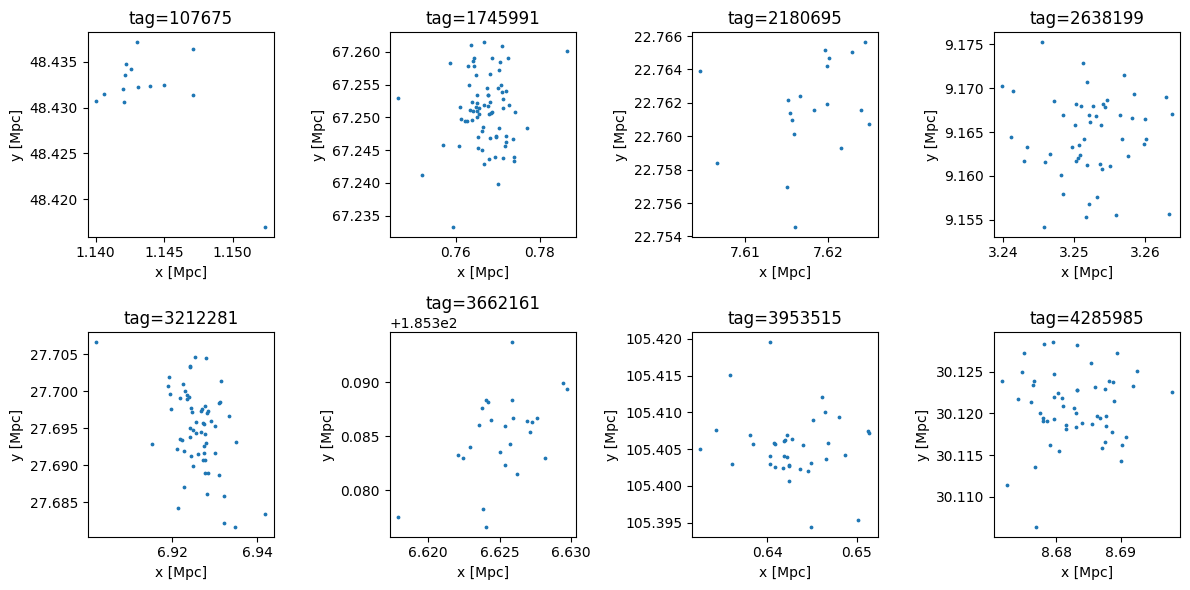

In [ ]:
#|eval: false
 
tags = np.unique(gal_tag).astype(int)
n_tags = 8 # len(tags)
tags = tags[:n_tags]  # Limit to first n_tags for testing
ncols = min(4, n_tags)
nrows = -(-n_tags // ncols)  # integer ceiling without math.ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = np.atleast_2d(axes)

for i, gal_tag_selected in enumerate(tags):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    gal_tag_cond = np.where(gal_tag == gal_tag_selected)
    ax.scatter(x[gal_tag_cond], y[gal_tag_cond], s=3, alpha=1.0)
    ax.set_title(f'tag={gal_tag_selected}')
    ax.set_xlabel('x [Mpc]')
    ax.set_ylabel('y [Mpc]')

for j in range(i+1, nrows*ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#|eval: false

def scatter_subset(x, y, hue, mask, **kws):
    sns.scatterplot(x=x[mask], y=y[mask], hue=hue[mask], **kws)

<Figure size 1000x1000 with 0 Axes>

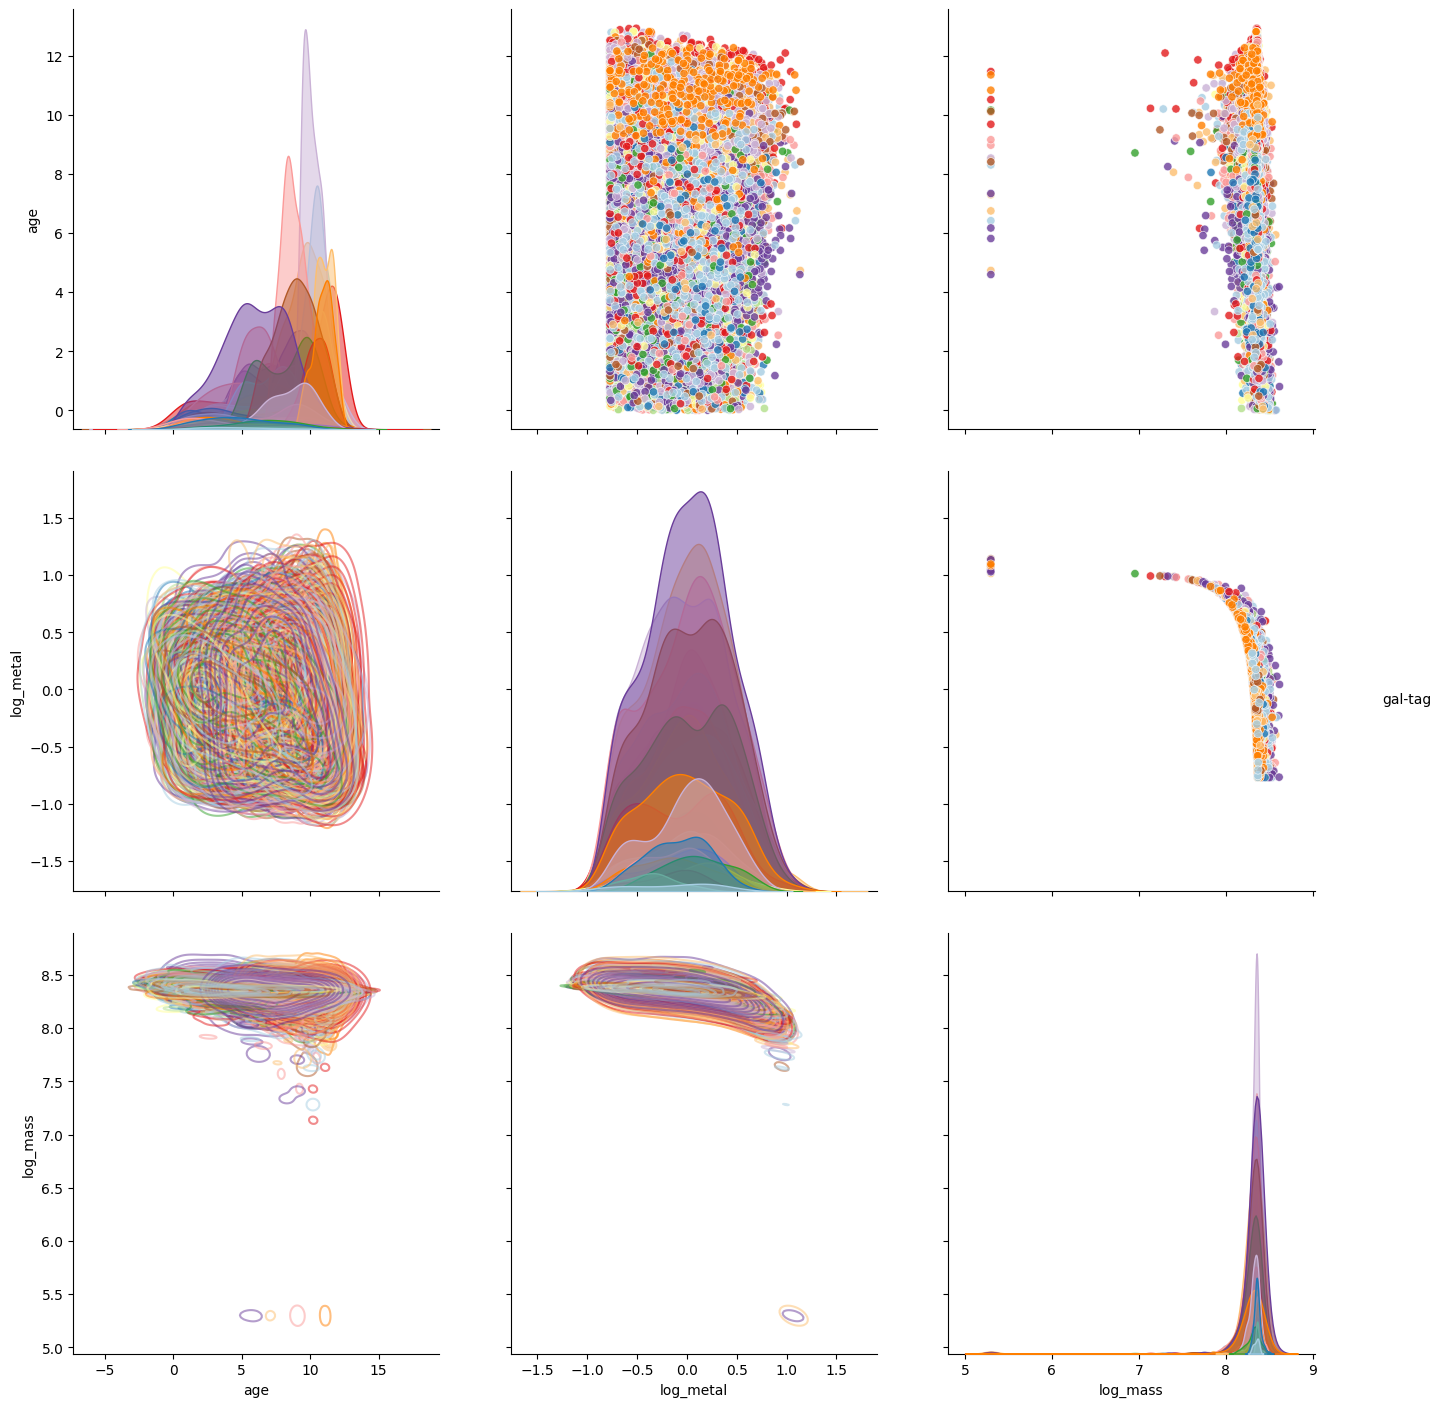

In [ ]:
#|eval: false

plt.figure(figsize=(10, 10))

df = pd.DataFrame(np.array([gal_tag, age, np.log10(metal + 1e-5), np.log10(mass)]).T, columns=['gal-tag', 'age','log_metal','log_mass'])
df1 = pd.DataFrame(np.array([age[gal_tag_cond], np.log10(metal + 1e-10)[gal_tag_cond], np.log10(mass)[gal_tag_cond]]).T, columns=['age','log_metal','log_mass'])


df_all = pd.concat([df.assign(dataset='all'), df1.assign(dataset='tag-select')])


g = sns.PairGrid(df, hue="gal-tag", palette = "Paired", diag_sharey=False)
# g.map_lower(scatter_subset, mask=df["gal-tag"] == np.unique(gal_tag)[0])
g.map_upper(scatter_subset, mask=df["gal-tag"] != 0, alpha=0.8, legend=False)
g.map_lower(sns.kdeplot, alpha=0.5, levels=10, legend=False, fill=False)
g.map_diag(sns.kdeplot, fill=True, legend=False, warn_singular=False, alpha=0.5)
g.add_legend()
g.fig.set_size_inches(15,15)

(array([4., 2., 1., 0., 3., 0., 2., 0., 0., 2.]),
 array([1.79797363, 2.61048746, 3.42300105, 4.23551464, 5.04802847,
        5.8605423 , 6.67305613, 7.48556995, 8.29808331, 9.11059761,
        9.92311096]),
 <BarContainer object of 10 artists>)

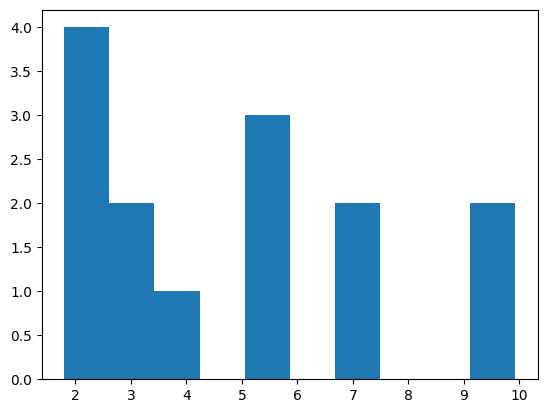

In [ ]:
#|eval: false

plt.hist(age[np.where(gal_tag == np.unique(gal_tag)[0])])

gal_tag_idx: 0, gal_tag: 107675
gal_tag_idx: 1, gal_tag: 1745991
gal_tag_idx: 2, gal_tag: 2180695
gal_tag_idx: 3, gal_tag: 2638199
gal_tag_idx: 4, gal_tag: 3212281


/lcrc/project/cosmo_ai/nramachandra/Projects/tmp/ipykernel_1934691/3070900267.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<matplotlib.legend.Legend>

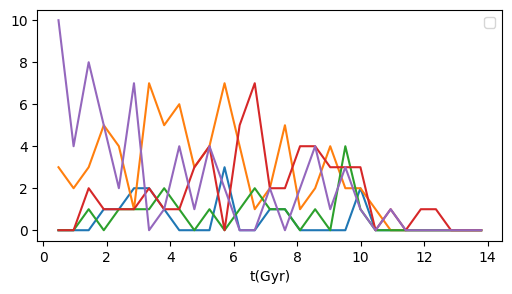

In [ ]:
#|eval: false

plt.figure(figsize=(6, 3))
for gal_tag_idx in range(5):
    print(f"gal_tag_idx: {gal_tag_idx}, gal_tag: {np.unique(gal_tag)[gal_tag_idx]}")
    gal_tag_condition = np.where(gal_tag == np.unique(gal_tag)[gal_tag_idx])
    h, b = np.histogram(age[gal_tag_condition], bins=np.linspace(0, 13.8, 30));
    # plt.plot(b[1:], np.cumsum(h), label='cumulative binned')
    # if (h.max() > 50):
    
    
    plt.plot(b[1:], h)
# plt.yscale('log')
plt.xlabel('t(Gyr)')
plt.legend()

In [ ]:
#| hide

import nbdev; nbdev.nbdev_export()